# Experiment 1: Synthetic Multilabel Risk Rectification with TabICL

Synthetic multilabel/retrieval-style experiment for risk rectification.

This notebook compares three methods:

1. **Standard CRC**: one global threshold.
2. **Oracle Rectified CRC**: local risk curves $R(\lambda \mid x)$ estimated via Monte Carlo from the known DGP, then calibrated by CRC.
3. **TabICL Rectified CRC**: estimated local risk surface via TabICL (Route 2 of the note).

The oracle is feasible here because the DGP is known: for each $x_i$ we can simulate fresh replicates $(Y_i^{(s)}, \text{scores}_i^{(s)})$ with the same difficulty and average the loss over the $\lambda$ grid. This serves the diagnostic role described in Section 6.2 of the note — it isolates the contribution of risk-curve estimation error from the contribution of the rectification idea itself.


## 1. Imports and configuration

In [1]:
!pip install tabicl torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 21.7 MB/s eta 0:00:00


In [2]:
import sys
import subprocess
import tabicl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from sklearn.isotonic import IsotonicRegression

from tabicl import TabICLRegressor


In [4]:
SEED = 123
rng = np.random.default_rng(SEED)

K_LABELS = 50

n_context = 500
n_cal = 500
n_test = 1000

alpha = 0.10
B_LOSS = 1.0

n_lambda = 101
lambda_grid = np.linspace(0.0, 1.0, n_lambda)

n_a = 80
a_grid = np.linspace(0.001, 0.5, n_a)

K_aug = 20
n_bins = 5

## 2. Synthetic multilabel DGP

In [5]:
def generate_multilabel_data(n, K=K_LABELS, rng=None, label_probs=None):
    """
    Synthetic multilabel/retrieval-style DGP.

    Larger X means harder examples:
    more relevant labels on average, less score separation, and noisier scores.

    The model outputs scores in [0, 1]. The true relevant set is Y.
    """
    if rng is None:
        rng = np.random.default_rng()

    X = rng.uniform(0, 1, size=n)
    difficulty = X

    mean_relevant = 2.0 + 6.0 * difficulty
    n_relevant = rng.poisson(mean_relevant)
    n_relevant = np.clip(n_relevant, 1, K)

    if label_probs is None:
        label_popularity = rng.normal(0, 0.7, size=K)
        label_probs = expit(label_popularity)
        label_probs = label_probs / label_probs.sum()

    Y = np.zeros((n, K), dtype=int)

    for i in range(n):
        pos_idx = rng.choice(K, size=n_relevant[i], replace=False, p=label_probs)
        Y[i, pos_idx] = 1

    # Easy examples: large separation and small noise.
    # Hard examples: smaller separation and larger noise.
    separation = 3.0 * (1.0 - difficulty) + 0.6
    noise_sd = 0.5 + 1.3 * difficulty

    logits = np.zeros((n, K))

    for i in range(n):
        signal = separation[i] * (2 * Y[i] - 1)
        logits[i] = signal + rng.normal(0, noise_sd[i], size=K)

    scores = expit(logits)

    return {
        "X": X,
        "difficulty": difficulty,
        "Y": Y,
        "scores": scores,
        "n_relevant": n_relevant,
        "label_probs": label_probs,
    }

## 3. Prediction sets and loss

In [6]:
def prediction_set(scores, lam):
    """
    Nested prediction set:
        C_lambda(x) = {k : score_k(x) >= 1 - lambda}.

    Larger lambda gives larger, more protective sets.
    """
    cutoff = 1.0 - lam
    return scores >= cutoff


def missed_positive_loss(scores, Y, lam):
    """
    False-negative proportion / missed-positive fraction:

        L_lambda(x, Y) = 1 - |Y cap C_lambda(x)| / |Y|.

    Assumes |Y| > 0.
    """
    C = prediction_set(scores, lam)
    n_pos = Y.sum(axis=1)
    hit_pos = (Y & C).sum(axis=1)
    return 1.0 - hit_pos / n_pos


def losses_over_lambda(scores, Y, lambda_grid):
    L = np.zeros((scores.shape[0], len(lambda_grid)))
    for j, lam in enumerate(lambda_grid):
        L[:, j] = missed_positive_loss(scores, Y, lam)
    return L

## 4. CRC calibration utilities

In [7]:
def crc_passes(loss_mean, n_cal, alpha, B=B_LOSS):
    """
    Standard CRC finite-sample correction:
        n/(n+1) * Rhat + B/(n+1) <= alpha.
    """
    return (n_cal / (n_cal + 1.0)) * loss_mean + B / (n_cal + 1.0) <= alpha


def calibrate_standard_crc(cal_scores, cal_Y, lambda_grid, alpha):
    """
    Standard CRC selects the smallest protective lambda that passes.
    Since larger lambda is more protective, risk decreases with lambda.
    """
    L_cal = losses_over_lambda(cal_scores, cal_Y, lambda_grid)
    mean_losses = L_cal.mean(axis=0)
    n_cal = cal_scores.shape[0]

    valid = np.array([
        crc_passes(mean_losses[j], n_cal, alpha, B=B_LOSS)
        for j in range(len(lambda_grid))
    ])

    idx = np.where(valid)[0][0] if np.any(valid) else len(lambda_grid) - 1
    return lambda_grid[idx], mean_losses


def invert_risk_curve(R_curve, lambda_grid, a):
    """
    Generalized inverse:
        inf {lambda : R(lambda | x) <= a}.
    """
    idx = np.where(R_curve <= a)[0]
    return lambda_grid[idx[0]] if len(idx) > 0 else lambda_grid[-1]


def monotonize_decreasing(R_curve, lambda_grid=lambda_grid):
    """
    Enforce non-increasing risk in lambda using isotonic regression.
    We fit an increasing curve to -R(lambda).
    """
    iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
    R_mono = -iso.fit_transform(lambda_grid, -R_curve)
    return np.clip(R_mono, 0.0, 1.0)

## 5. Route 2: risk surface estimation with TabICL

In [8]:
def score_summary_features(scores):
    """Simple image/query-level summaries of the score vector."""
    s_sorted = np.sort(scores)
    return {
        "score_mean": scores.mean(),
        "score_std": scores.std(),
        "score_max": scores.max(),
        "score_top5_mean": s_sorted[-5:].mean(),
        "score_mass": scores.sum(),
        "score_gap_top2": s_sorted[-1] - s_sorted[-2],
    }


def build_augmented_context(data_context, lambda_grid, K_aug=20, rng=None):
    """
    Build the augmented context dataset for Route 2:
        (x_i, lambda_ik, score summaries) -> L_{lambda_ik}(x_i, Y_i).
    """
    if rng is None:
        rng = np.random.default_rng()

    X = data_context["X"]
    scores = data_context["scores"]
    Y = data_context["Y"]

    rows, targets = [], []

    for i in range(len(X)):
        lam_samples = rng.choice(lambda_grid, size=K_aug, replace=True)
        sf = score_summary_features(scores[i])

        for lam in lam_samples:
            loss = missed_positive_loss(
                scores=scores[i].reshape(1, -1),
                Y=Y[i].reshape(1, -1),
                lam=lam,
            )[0]

            rows.append([
                X[i], lam, sf["score_mean"], sf["score_std"], sf["score_max"],
                sf["score_top5_mean"], sf["score_mass"], sf["score_gap_top2"],
            ])
            targets.append(loss)

    X_aug = pd.DataFrame(
        rows,
        columns=[
            "x", "lambda", "score_mean", "score_std", "score_max",
            "score_top5_mean", "score_mass", "score_gap_top2",
        ],
    )

    return X_aug, np.asarray(targets)


def make_features_for_risk(data, lambda_grid):
    """Create features for all pairs (observation, lambda)."""
    X = data["X"]
    scores = data["scores"]

    rows, index = [], []

    for i in range(len(X)):
        sf = score_summary_features(scores[i])

        for lam in lambda_grid:
            rows.append([
                X[i], lam, sf["score_mean"], sf["score_std"], sf["score_max"],
                sf["score_top5_mean"], sf["score_mass"], sf["score_gap_top2"],
            ])
            index.append(i)

    X_pred = pd.DataFrame(
        rows,
        columns=[
            "x", "lambda", "score_mean", "score_std", "score_max",
            "score_top5_mean", "score_mass", "score_gap_top2",
        ],
    )

    return X_pred, np.asarray(index)


def fit_tabicl_risk_surface(data_context, lambda_grid, K_aug=20, rng=None):
    """
    Fit TabICLRegressor to estimate:
        g(x, lambda) ≈ R(lambda | x).
    """
    X_aug, y_aug = build_augmented_context(
        data_context=data_context,
        lambda_grid=lambda_grid,
        K_aug=K_aug,
        rng=rng,
    )

    reg = TabICLRegressor()
    reg.fit(X_aug, y_aug)

    return reg, X_aug, y_aug


def estimate_risk_matrix_tabicl(reg, data, lambda_grid):
    """
    Estimate R(lambda | x_i) for every observation i and every lambda.
    """
    X_pred, index = make_features_for_risk(data, lambda_grid)

    y_pred = reg.predict(X_pred)
    y_pred = np.clip(y_pred, 0.0, 1.0)

    n = len(data["X"])
    R_mat = np.zeros((n, len(lambda_grid)))

    for i in range(n):
        vals = y_pred[index == i]
        R_mat[i] = monotonize_decreasing(vals, lambda_grid=lambda_grid)

    return R_mat

## 6. Rectified calibration

In [9]:
def lambda_from_risk_matrix(R_mat, lambda_grid, a):
    """
    Compute lambda_i(a) = R^{-1}(a | x_i) for all observations.
    """
    out = np.zeros(R_mat.shape[0])
    for i in range(R_mat.shape[0]):
        out[i] = invert_risk_curve(R_mat[i], lambda_grid, a)
    return out


def calibrate_rectified(cal_scores, cal_Y, R_cal_mat, lambda_grid, a_grid, alpha):
    """
    Calibrate the risk budget a using CRC over the rectified family.
    Larger a is less protective, so we choose the largest a that passes.
    """
    n_cal = cal_scores.shape[0]
    losses_by_a = []

    for a in a_grid:
        lambda_i = lambda_from_risk_matrix(R_cal_mat, lambda_grid, a)

        loss_i = np.zeros(n_cal)
        for i in range(n_cal):
            loss_i[i] = missed_positive_loss(
                scores=cal_scores[i].reshape(1, -1),
                Y=cal_Y[i].reshape(1, -1),
                lam=lambda_i[i],
            )[0]

        losses_by_a.append(loss_i.mean())

    losses_by_a = np.asarray(losses_by_a)

    valid = np.array([
        crc_passes(losses_by_a[j], n_cal, alpha, B=B_LOSS)
        for j in range(len(a_grid))
    ])

    idx = np.where(valid)[0][-1] if np.any(valid) else 0
    return a_grid[idx], losses_by_a

## 7. Evaluation metrics

In [10]:
def evaluate_method(data_test, lambda_vec, method_name, alpha, n_bins=5):
    scores = data_test["scores"]
    Y = data_test["Y"]
    difficulty = data_test["difficulty"]

    n = len(difficulty)

    loss = np.zeros(n)
    set_size = np.zeros(n)

    for i in range(n):
        lam = lambda_vec[i]

        loss[i] = missed_positive_loss(
            scores=scores[i].reshape(1, -1),
            Y=Y[i].reshape(1, -1),
            lam=lam,
        )[0]

        set_size[i] = prediction_set(scores=scores[i].reshape(1, -1), lam=lam).sum()

    bins = pd.qcut(difficulty, q=n_bins, labels=False, duplicates="drop")
    unique_bins = np.sort(pd.Series(bins).dropna().unique())

    R_bins = np.array([loss[bins == g].mean() for g in unique_bins])
    size_bins = np.array([set_size[bins == g].mean() for g in unique_bins])
    lambda_bins = np.array([lambda_vec[bins == g].mean() for g in unique_bins])

    return {
        "method": method_name,
        "R_test": loss.mean(),
        "worst_bin_risk": np.nanmax(R_bins),
        "worst_bin_ratio": np.nanmax(R_bins) / alpha,
        "mean_bin_excess": np.nanmean(np.maximum(R_bins - alpha, 0)),
        "mean_set_size": set_size.mean(),
        "lambda_mean": lambda_vec.mean(),
        "lambda_sd": lambda_vec.std(ddof=1),
        "R_bins": R_bins,
        "size_bins": size_bins,
        "lambda_bins": lambda_bins,
        "lambda_vec": lambda_vec,
        "loss": loss,
        "set_size": set_size,
    }

## 8. Generate context/calibration/test splits

In [11]:
rng = np.random.default_rng(SEED)

# Use one label-probability vector across all splits for consistency.
data_tmp = generate_multilabel_data(1, rng=rng)
label_probs = data_tmp["label_probs"]

data_context = generate_multilabel_data(n_context, rng=rng, label_probs=label_probs)
data_cal = generate_multilabel_data(n_cal, rng=rng, label_probs=label_probs)
data_test = generate_multilabel_data(n_test, rng=rng, label_probs=label_probs)

print("Context:", len(data_context["X"]))
print("Calibration:", len(data_cal["X"]))
print("Test:", len(data_test["X"]))

Context: 500
Calibration: 500
Test: 1000


## 9. Standard CRC

In [12]:
lambda_crc, crc_cal_curve = calibrate_standard_crc(
    cal_scores=data_cal["scores"],
    cal_Y=data_cal["Y"],
    lambda_grid=lambda_grid,
    alpha=alpha,
)

lambda_crc_test = np.repeat(lambda_crc, n_test)

eval_crc = evaluate_method(
    data_test=data_test,
    lambda_vec=lambda_crc_test,
    method_name="Standard CRC",
    alpha=alpha,
    n_bins=n_bins,
)

print("Standard CRC lambda:", lambda_crc)
{k: v for k, v in eval_crc.items() if not isinstance(v, np.ndarray)}

Standard CRC lambda: 0.5


{'method': 'Standard CRC',
 'R_test': np.float64(0.09728226495726496),
 'worst_bin_risk': np.float64(0.29726180763680765),
 'worst_bin_ratio': np.float64(2.9726180763680765),
 'mean_bin_excess': np.float64(0.04850596625596625),
 'mean_set_size': np.float64(8.384),
 'lambda_mean': np.float64(0.5),
 'lambda_sd': np.float64(0.0)}

## 10. TabICL Rectified CRC

In [13]:
print("Fitting TabICL risk surface...")

tabicl_risk_model, X_aug, y_aug = fit_tabicl_risk_surface(
    data_context=data_context,
    lambda_grid=lambda_grid,
    K_aug=K_aug,
    rng=rng,
)

print("Augmented context shape:", X_aug.shape)
print("Estimating TabICL risk matrices...")

R_tabicl_cal = estimate_risk_matrix_tabicl(
    reg=tabicl_risk_model,
    data=data_cal,
    lambda_grid=lambda_grid,
)

R_tabicl_test = estimate_risk_matrix_tabicl(
    reg=tabicl_risk_model,
    data=data_test,
    lambda_grid=lambda_grid,
)

a_tabicl, tabicl_cal_curve = calibrate_rectified(
    cal_scores=data_cal["scores"],
    cal_Y=data_cal["Y"],
    R_cal_mat=R_tabicl_cal,
    lambda_grid=lambda_grid,
    a_grid=a_grid,
    alpha=alpha,
)

lambda_tabicl_test = lambda_from_risk_matrix(
    R_tabicl_test,
    lambda_grid=lambda_grid,
    a=a_tabicl,
)

eval_tabicl = evaluate_method(
    data_test=data_test,
    lambda_vec=lambda_tabicl_test,
    method_name="TabICL Rectified",
    alpha=alpha,
    n_bins=n_bins,
)

print("TabICL calibrated a:", a_tabicl)
{k: v for k, v in eval_tabicl.items() if not isinstance(v, np.ndarray)}

Fitting TabICL risk surface...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



tabicl-regressor-v2-20260212.ckpt:   0%|          | 0.00/114M [00:00<?, ?B/s]

Augmented context shape: (10000, 8)
Estimating TabICL risk matrices...
TabICL calibrated a: 0.08943037974683544


{'method': 'TabICL Rectified',
 'R_test': np.float64(0.0924095571095571),
 'worst_bin_risk': np.float64(0.1174470251970252),
 'worst_bin_ratio': np.float64(1.174470251970252),
 'mean_bin_excess': np.float64(0.007158330558330558),
 'mean_set_size': np.float64(11.209),
 'lambda_mean': np.float64(0.38053000000000003),
 'lambda_sd': np.float64(0.2652866300741447)}

## 10b. Oracle Rectified CRC (Monte Carlo from the known DGP)

Since the DGP is known, we can approximate the true local risk curve $R(\lambda \mid x_i)$ for each calibration and test point by Monte Carlo: we simulate $S$ fresh replicates of $(Y, \text{scores})$ conditional on $x_i$ (with the same difficulty, separation, and noise level), then average the missed-positive loss across the $\lambda$ grid.

This is the oracle in the sense of Section 4.1 of the note (Route 1, estimate $Y \mid x$ then average the loss), but with replicates drawn directly from the true conditional law instead of from a learned $p_\phi(y \mid x, \mathcal{D})$. CRC is then applied to the resulting rectified family exactly as in the TabICL version.


In [14]:
def replicate_at_x(x_value, label_probs, n_mc, K=K_LABELS, rng=None):
    """
    Simulate `n_mc` fresh (Y, scores) replicates conditional on X = x_value,
    using the same DGP parameters (difficulty, separation, noise) as
    `generate_multilabel_data`.

    Returns Y_rep of shape (n_mc, K) and scores_rep of shape (n_mc, K).
    """
    if rng is None:
        rng = np.random.default_rng()

    difficulty = x_value
    mean_relevant = 2.0 + 6.0 * difficulty
    separation = 3.0 * (1.0 - difficulty) + 0.6
    noise_sd = 0.5 + 1.3 * difficulty

    n_relevant = np.clip(rng.poisson(mean_relevant, size=n_mc), 1, K)

    Y_rep = np.zeros((n_mc, K), dtype=int)
    for s in range(n_mc):
        pos_idx = rng.choice(K, size=n_relevant[s], replace=False, p=label_probs)
        Y_rep[s, pos_idx] = 1

    signal = separation * (2 * Y_rep - 1)
    noise = rng.normal(0, noise_sd, size=(n_mc, K))
    scores_rep = expit(signal + noise)

    return Y_rep, scores_rep


def oracle_risk_matrix_mc(data, lambda_grid, label_probs, n_mc=200, rng=None):
    """
    Monte Carlo estimate of R(lambda | x_i) for every i and every lambda in the grid.
    Uses replicates drawn from the true DGP conditional on X = x_i.

    The same sampled (Y_rep, scores_rep) are used across all lambdas, which
    preserves monotonicity of the Monte Carlo curve in lambda for fixed x.
    """
    if rng is None:
        rng = np.random.default_rng()

    X = data["X"]
    n = len(X)
    n_lam = len(lambda_grid)
    R_mat = np.zeros((n, n_lam))

    for i in range(n):
        Y_rep, scores_rep = replicate_at_x(
            x_value=X[i],
            label_probs=label_probs,
            n_mc=n_mc,
            rng=rng,
        )
        n_pos = Y_rep.sum(axis=1)

        for j, lam in enumerate(lambda_grid):
            C = scores_rep >= (1.0 - lam)
            hit = (Y_rep & C).sum(axis=1)
            R_mat[i, j] = (1.0 - hit / n_pos).mean()

    return R_mat


In [15]:
n_mc_oracle = 200

print("Estimating oracle Monte Carlo risk matrices...")

rng_oracle = np.random.default_rng(SEED + 99)

R_oracle_cal = oracle_risk_matrix_mc(
    data=data_cal,
    lambda_grid=lambda_grid,
    label_probs=label_probs,
    n_mc=n_mc_oracle,
    rng=rng_oracle,
)

R_oracle_test = oracle_risk_matrix_mc(
    data=data_test,
    lambda_grid=lambda_grid,
    label_probs=label_probs,
    n_mc=n_mc_oracle,
    rng=rng_oracle,
)

print("R_oracle_cal shape:", R_oracle_cal.shape)
print("R_oracle_test shape:", R_oracle_test.shape)


Estimating oracle Monte Carlo risk matrices...
R_oracle_cal shape: (500, 101)
R_oracle_test shape: (1000, 101)


In [17]:
a_oracle, oracle_cal_curve = calibrate_rectified(
    cal_scores=data_cal["scores"],
    cal_Y=data_cal["Y"],
    R_cal_mat=R_oracle_cal,
    lambda_grid=lambda_grid,
    a_grid=a_grid,
    alpha=alpha,
)

lambda_oracle_test = lambda_from_risk_matrix(
    R_oracle_test,
    lambda_grid=lambda_grid,
    a=a_oracle,
)

eval_oracle = evaluate_method(
    data_test=data_test,
    lambda_vec=lambda_oracle_test,
    method_name="Oracle Rectified",
    alpha=alpha,
    n_bins=n_bins,
)

print("Oracle calibrated a:", a_oracle)
{k: v for k, v in eval_oracle.items() if not isinstance(v, np.ndarray)}


Oracle calibrated a: 0.10206329113924051


{'method': 'Oracle Rectified',
 'R_test': np.float64(0.09693037795537797),
 'worst_bin_risk': np.float64(0.10802453102453104),
 'worst_bin_ratio': np.float64(1.0802453102453102),
 'mean_bin_excess': np.float64(0.001987029637029633),
 'mean_set_size': np.float64(11.203),
 'lambda_mean': np.float64(0.38916),
 'lambda_sd': np.float64(0.25501358067037594)}

## 11. Summary table

In [18]:
eval_tabicl

{'method': 'TabICL Rectified',
 'R_test': np.float64(0.0924095571095571),
 'worst_bin_risk': np.float64(0.1174470251970252),
 'worst_bin_ratio': np.float64(1.174470251970252),
 'mean_bin_excess': np.float64(0.007158330558330558),
 'mean_set_size': np.float64(11.209),
 'lambda_mean': np.float64(0.38053000000000003),
 'lambda_sd': np.float64(0.2652866300741447),
 'R_bins': array([0.05079167, 0.07546447, 0.11444535, 0.10389928, 0.11744703]),
 'size_bins': array([ 2.525,  3.77 ,  5.335, 15.06 , 29.355]),
 'lambda_bins': array([0.07455, 0.16545, 0.33755, 0.5867 , 0.7384 ]),
 'lambda_vec': array([0.04, 0.67, 0.21, 0.81, 0.77, 0.35, 0.11, 0.33, 0.19, 0.27, 0.3 ,
        0.17, 0.15, 0.34, 0.11, 0.68, 0.79, 0.81, 0.64, 0.65, 0.09, 0.02,
        0.57, 0.51, 0.05, 0.04, 0.56, 0.95, 0.12, 0.61, 0.51, 0.27, 0.55,
        0.05, 0.04, 0.74, 0.06, 0.09, 0.82, 0.11, 0.54, 0.75, 0.05, 0.77,
        0.05, 0.12, 0.11, 0.09, 0.07, 0.1 , 0.23, 0.24, 0.69, 0.05, 0.1 ,
        0.1 , 0.69, 0.26, 0.07, 0.79, 0.

In [19]:
evals = [eval_crc, eval_oracle, eval_tabicl]

summary = pd.DataFrame([
    {
        "method": e["method"],
        "R_test": e["R_test"],
        "worst_bin_risk": e["worst_bin_risk"],
        "worst_bin_ratio": e["worst_bin_ratio"],
        "mean_bin_excess": e["mean_bin_excess"],
        "mean_set_size": e["mean_set_size"],
        "lambda_mean": e["lambda_mean"],
        "lambda_sd": e["lambda_sd"],
    }
    for e in evals
])

summary


,method,R_test,worst_bin_risk,worst_bin_ratio,mean_bin_excess,mean_set_size,lambda_mean,lambda_sd
0,Standard CRC,0.097282,0.297262,2.972618,0.048506,8.384,0.50000,0.000000
1,Oracle Rectified,0.096930,0.108025,1.080245,0.001987,11.203,0.38916,0.255014
2,TabICL Rectified,0.092410,0.117447,1.174470,0.007158,11.209,0.38053,0.265287


## 12. Plots

In [20]:
colors = {
    "Standard CRC": "#999999",
    "Oracle Rectified": "#0067b1",   # azulclaro UFSCar
    "TabICL Rectified": "#002f6c",   # azulescuro UFSCar
}


### 12.1 Risk by difficulty bin

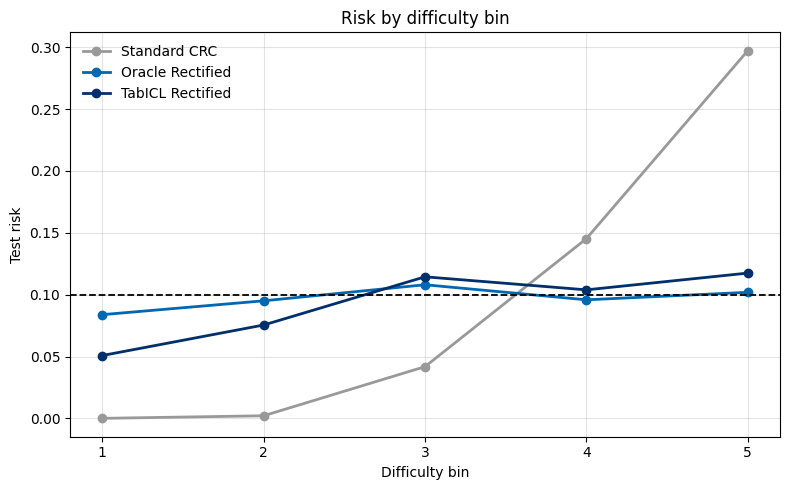

In [21]:
plt.figure(figsize=(8, 5))

for e in evals:
    plt.plot(
        np.arange(1, len(e["R_bins"]) + 1),
        e["R_bins"],
        "o-",
        linewidth=2,
        label=e["method"],
        color=colors[e["method"]],
    )

plt.axhline(alpha, color="black", linestyle="--", linewidth=1.3)
plt.xlabel("Difficulty bin")
plt.ylabel("Test risk")
plt.title("Risk by difficulty bin")
plt.xticks(np.arange(1, n_bins + 1))
plt.legend(frameon=False)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rectification-crc/exp_2_risk_by_difficulty_bin_no_oracle.png", dpi=200, bbox_inches="tight")
plt.show()

### 12.2 Prediction-set size by difficulty bin

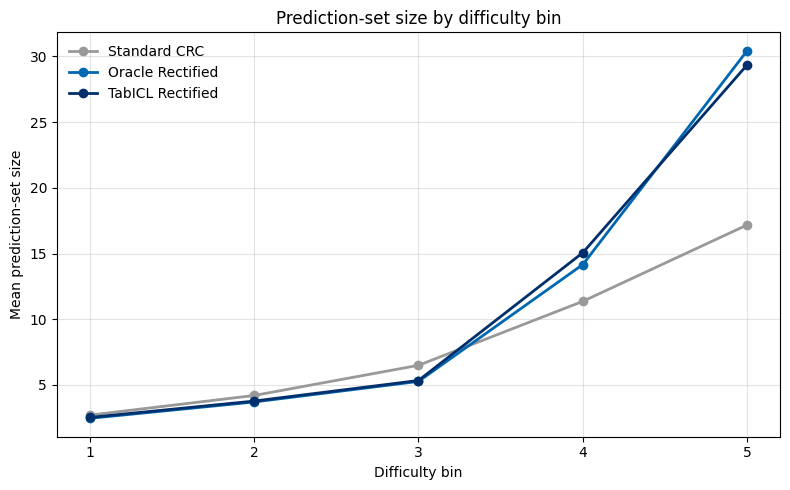

In [23]:
plt.figure(figsize=(8, 5))

for e in evals:
    plt.plot(
        np.arange(1, len(e["size_bins"]) + 1),
        e["size_bins"],
        "o-",
        linewidth=2,
        label=e["method"],
        color=colors[e["method"]],
    )

plt.xlabel("Difficulty bin")
plt.ylabel("Mean prediction-set size")
plt.title("Prediction-set size by difficulty bin")
plt.xticks(np.arange(1, n_bins + 1))
plt.legend(frameon=False)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rectification-crc/exp_2_set_size_by_difficulty_bin_no_oracle.png", dpi=200, bbox_inches="tight")
plt.show()

### 12.3 Worst-bin risk relative to target

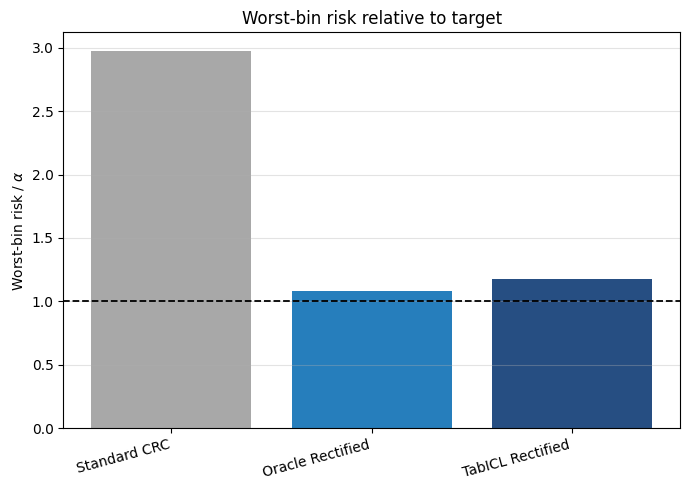

In [24]:
plt.figure(figsize=(7, 5))

methods = [e["method"] for e in evals]

plt.bar(
    methods,
    [e["worst_bin_ratio"] for e in evals],
    color=[colors[m] for m in methods],
    alpha=0.85,
)

plt.axhline(1.0, color="black", linestyle="--", linewidth=1.3)
plt.ylabel(r"Worst-bin risk / $\alpha$")
plt.title("Worst-bin risk relative to target")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rectification-crc/exp_2_worst_bin_risk_ratio_no_oracle.png", dpi=200, bbox_inches="tight")
plt.show()

### 12.4 Selected threshold by difficulty

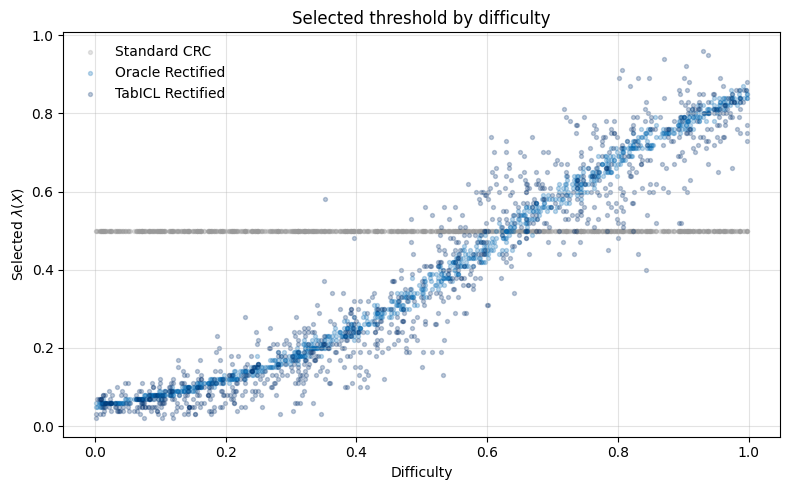

In [25]:
plt.figure(figsize=(8, 5))

for e in evals:
    plt.scatter(
        data_test["difficulty"],
        e["lambda_vec"],
        s=8,
        alpha=0.25,
        label=e["method"],
        color=colors[e["method"]],
    )

plt.xlabel("Difficulty")
plt.ylabel(r"Selected $\lambda(X)$")
plt.title("Selected threshold by difficulty")
plt.legend(frameon=False)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rectification-crc/exp_2_lambda_by_difficulty_no_oracle.png", dpi=200, bbox_inches="tight")
plt.show()

### 12.5 Calibration curves

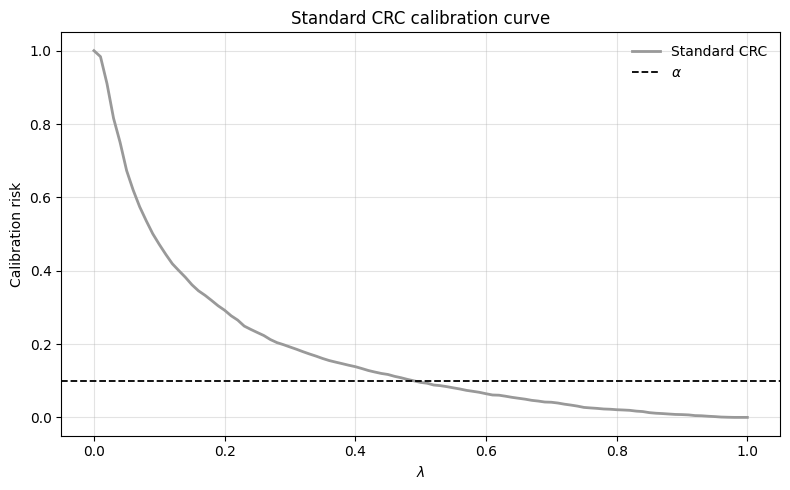

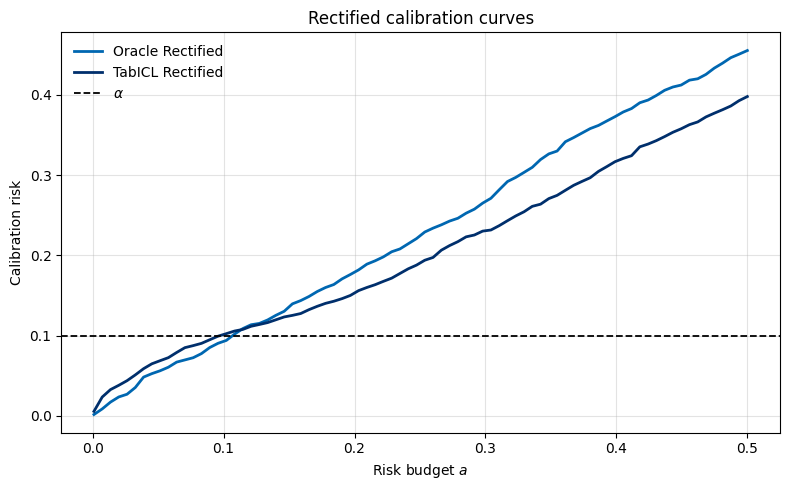

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(lambda_grid, crc_cal_curve, linewidth=2, color=colors["Standard CRC"], label="Standard CRC")
plt.axhline(alpha, color="black", linestyle="--", linewidth=1.3, label=r"$\alpha$")

plt.xlabel(r"$\lambda$")
plt.ylabel("Calibration risk")
plt.title("Standard CRC calibration curve")
plt.legend(frameon=False)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rectification-crc/exp_2_standard_crc_calibration_curve.png", dpi=200, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(a_grid, oracle_cal_curve, linewidth=2, color=colors["Oracle Rectified"], label="Oracle Rectified")
plt.plot(a_grid, tabicl_cal_curve, linewidth=2, color=colors["TabICL Rectified"], label="TabICL Rectified")
plt.axhline(alpha, color="black", linestyle="--", linewidth=1.3, label=r"$\alpha$")

plt.xlabel("Risk budget $a$")
plt.ylabel("Calibration risk")
plt.title("Rectified calibration curves")
plt.legend(frameon=False)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rectification-crc/exp_2_rectified_calibration_curves.png", dpi=200, bbox_inches="tight")
plt.show()


## 13. Inspect the augmented context data

In [ ]:
X_aug.head()

,x,lambda,score_mean,score_std,score_max,score_top5_mean,score_mass,score_gap_top2
0,0.149053,0.67,0.070855,0.132908,0.979598,0.292917,3.542761,0.833219
1,0.149053,0.86,0.070855,0.132908,0.979598,0.292917,3.542761,0.833219
2,0.149053,0.01,0.070855,0.132908,0.979598,0.292917,3.542761,0.833219
3,0.149053,0.86,0.070855,0.132908,0.979598,0.292917,3.542761,0.833219
4,0.149053,0.12,0.070855,0.132908,0.979598,0.292917,3.542761,0.833219


In [ ]:
pd.Series(y_aug).describe()

,0
count,10000.000000
mean,0.189302
std,0.303512
min,0.000000
25%,0.000000
50%,0.000000
75%,0.333333
max,1.000000
